In [7]:
import os
import sys
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

repo_root = Path.cwd().parent.parent.parent.parent
sys.path.insert(0, str(repo_root))
import SysSimX

repo_root = Path.cwd().parent.parent
sys.path.insert(0, str(repo_root))
from MyModels.MasterPendulum.pendulum_ode import PendulumODE, ramp_torque, constant_torque
from fem_pendulum import FEMPendulum
import pendulum_config as config

-------------------------------

**Instantiate and Configure FEM Pendulum**

In [8]:
model = FEMPendulum(name="FEM_Pendulum", group="Plant")

mesh_params = config.MeshParameters()
mesh_params.max_element_size = 0.1 / 6

init_params = config.InitialConditionParameters()
init_params.angular_position_deg = 0  # Initial angle
q0 = np.deg2rad(init_params.angular_position_deg)
init_params.drive_torque = 40 # Nm

sim_params = config.SimulationParameters()
sim_params.tau = 0.01
sim_params.t_end = 1
sim_params.with_contact = False
sim_params.use_gravity = True

anim_params = config.AnimationParameters()
anim_params.animate = False

model.set_parameters(
    init_params=init_params,
    sim_params=sim_params,
    anim_params=anim_params,
    mesh_params=mesh_params
)

model.initialize(0.0)
model.setup_monitoring()
model.display_monitoring()
model.initialize_scene()

HTML(value="<h3 style='color:#1565c0; font-family:Inter, sans-serif; margin:15px 0 20px 0; text-align:center; …

WebGuiWidget(layout=Layout(height='500px', width='100%'), value={'gui_settings': {}, 'ngsolve_version': '6.2.2…

In [9]:
# After model.initialize(0.0)
fem_torque = model._compute_fem_gravity_torque()
rigid_torque = model._gravity_torque(q0)

print(f"\nTorque Comparison:")
print(f"FEM distributed torque:  {fem_torque:.4f} Nm")
print(f"Rigid body point torque: {rigid_torque:.4f} Nm")
print(f"Torque ratio: {fem_torque/rigid_torque:.6f}")


Torque Comparison:
FEM distributed torque:  0.0000 Nm
Rigid body point torque: 0.0000 Nm
Torque ratio: inf


In [10]:
model.get_outputs()

{'q': <Quantity(0.0, 'radian')>,
 'omega': <Quantity(0.0, 'radian / second')>,
 'alpha': <Quantity(2.11636273, 'radian / second ** 2')>}

In [11]:
t_end = model.sim_params.t_end
dt = model.sim_params.tau
t = 0.0

torque_amp = init_params.drive_torque
#torque_func: callable = ramp_torque(t_end, torque_amp)
torque_func: callable = constant_torque(torque_amp)

# Analytical Solution using ODE Pendulum
pendulum_ode = PendulumODE(mass=model.mass,
                           length=model._equivalent_length,
                           inertia=model.inertia,
                           g= 9.81 if model.sim_params.use_gravity else 0.0)


t_an_vals, q_an_vals, omega_an_vals, alpha_an_vals = pendulum_ode.solve(t_span=(0.0, t_end),
                                                    y0=[np.deg2rad(init_params.angular_position_deg), 0.0],
                                                    torque_func=torque_func,
                                                    dt=dt)

In [12]:
while t < t_end:
    # 1) Compute input torque
    torque = torque_func(t)
    
    # 2) Perform simulation step
    model.set_inputs({'torque': torque}, t=t)

    # 3) Integrate one time step
    model.do_step(t, dt)

    # 4) Advance time
    t += dt

In [13]:
results = model.get_history()

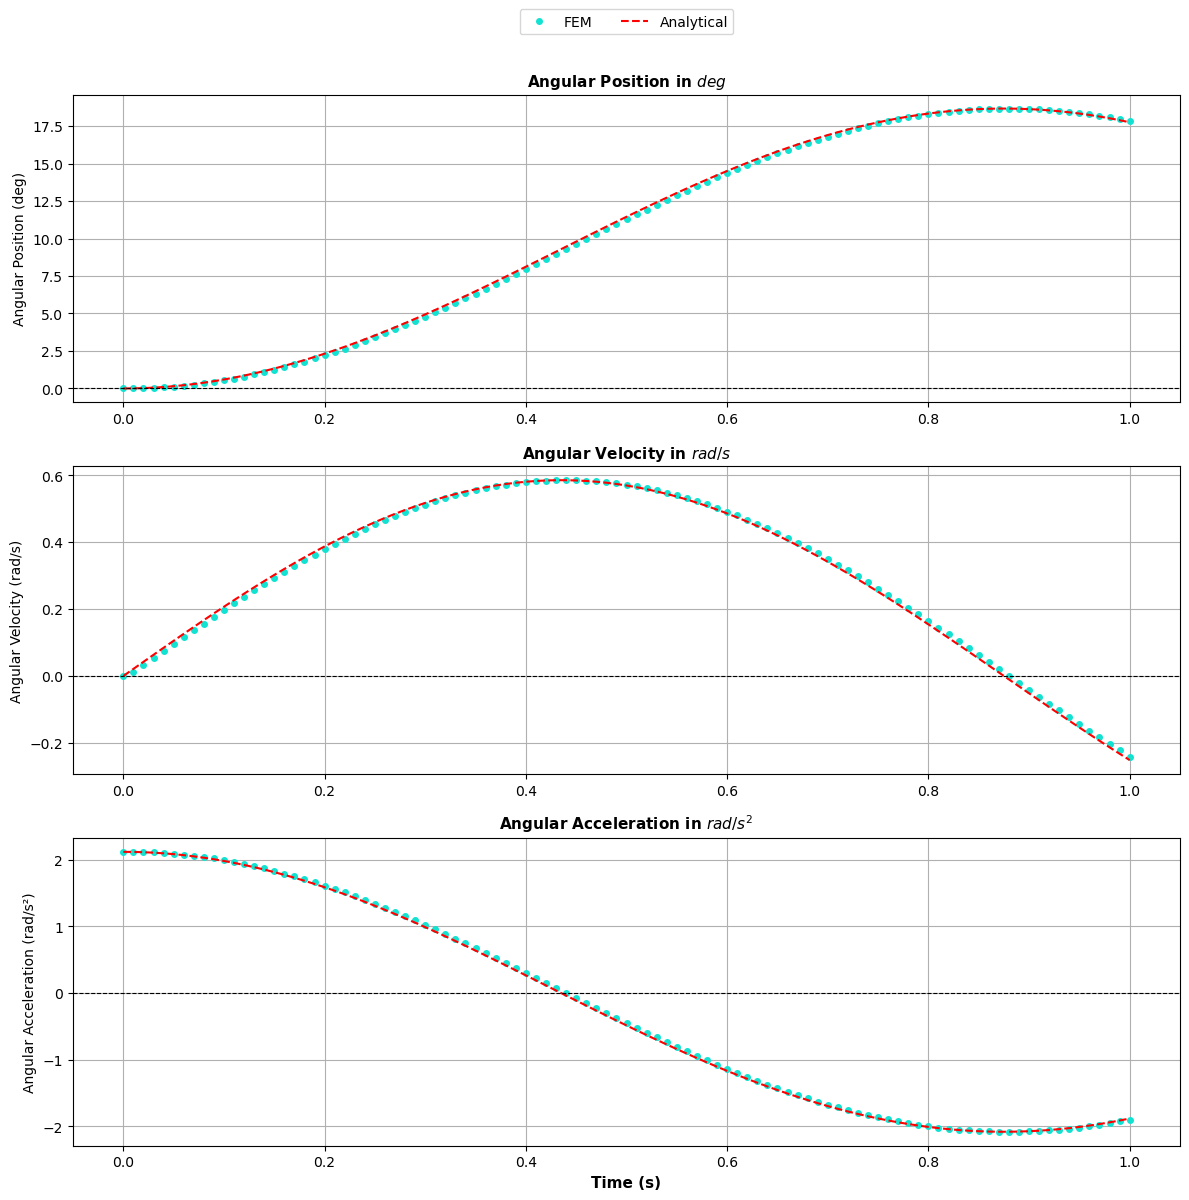

In [14]:
t_vals = results['q']['time']
q_fem_vals = results['q']['values']
omega_fem_vals = results['omega']['values']
alpha_fem_vals = results['alpha']['values']

marker_size = 4
fem_style = {'color': "#12e2d1", 'linestyle': 'None', 'marker': 'o', 'markersize': marker_size, 'linewidth': 3.5}  
opensim_style = {'color': "#f8c20f", 'linestyle': 'None', 'marker': 's', 'markersize': marker_size, 'linewidth': 3.5} 
eqb_style = {'color': "#1d8d43", 'linestyle': 'None', 'marker': '^', 'markersize': marker_size, 'linewidth': 3.5}
fontdict = {'fontsize': 11, 'fontweight': 'bold'}

plt.figure(figsize=(12, 12))

plt.subplot(3,1,1).set_title("Angular Position in $deg$", **fontdict)
plt.plot(t_vals, np.rad2deg(q_fem_vals), label="FEM", **fem_style)
plt.plot(t_an_vals, np.rad2deg(q_an_vals), label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Position (deg)")
plt.grid(which='both')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, 1.3), ncol=4)

plt.subplot(3,1,2).set_title("Angular Velocity in $rad/s$", **fontdict)
plt.plot(t_vals, omega_fem_vals, label="FEM", **fem_style)
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.plot(t_an_vals, omega_an_vals, label="Analytical", color='red', linestyle='--')
plt.ylabel("Angular Velocity (rad/s)")
plt.grid(which='both')

plt.subplot(3,1,3).set_title("Angular Acceleration in $rad/s^2$", **fontdict)
plt.plot(t_vals, alpha_fem_vals, label="FEM", **fem_style)
plt.plot(t_an_vals, alpha_an_vals, label="Analytical", color='red', linestyle='--')
plt.axhline(0, color='k', linestyle='--', linewidth=0.8)
plt.ylabel("Angular Acceleration (rad/s²)")
plt.grid(which='both')

plt.xlabel("Time (s)", **fontdict)
plt.tight_layout()
#plt.savefig("../figures/StateSynchronization_driven.svg")
plt.show()

In [19]:
mass = model.mass
inertia = model.inertia
q0 = init_params.angular_position_deg
init_grav_torque = model._gravity_torque(np.deg2rad(q0))
init_torque = model.init_params.drive_torque
total_init_torque = init_torque - init_grav_torque
expected_alpha0 = total_init_torque / inertia

alpha_grav = -init_grav_torque / inertia
alpha_drive = init_torque / inertia
alpha_actual = alpha_grav + alpha_drive

print("\nGravitational Acceleration Test:")
print(f"Mass: {mass:.4f} kg")
print(f"Inertia: {inertia:.4f} kgm²")
print(f"Initial angle: {q0:.4f} deg")
print(f"Initial gravitational torque: {init_grav_torque:.4f} Nm")
print(f"Expected alpha0: {expected_alpha0:.4f} rad/s²")
print(f"Actual alpha0:   {alpha_fem_vals[0]:.4f} rad/s²")

error = np.abs(alpha_actual - alpha_grav) / np.abs(alpha_grav) * 100
print(f"Relative error: {error:.6f} %")
ratio = alpha_actual / alpha_grav
print(f"Ratio actual/expected: {ratio:.6f}")


Gravitational Acceleration Test:
Mass: 41.7037 kg
Inertia: 18.9004 kgm²
Initial angle: 0.0000 deg
Initial gravitational torque: 0.0000 Nm
Expected alpha0: 2.1164 rad/s²
Actual alpha0:   2.1164 rad/s²
Relative error: inf %
Ratio actual/expected: -inf


---------------------